In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
import optuna
import joblib
import warnings
from tqdm import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

Cargamos los datos para nuestro modelo

In [10]:
df = pd.read_csv("../csv/clean_cars.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192378 entries, 0 to 192377
Data columns (total 79 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   brand                192378 non-null  object 
 1   model                192378 non-null  object 
 2   model_year           192378 non-null  int64  
 3   milage               192378 non-null  int64  
 4   fuel_type            192378 non-null  object 
 5   transmission         192378 non-null  object 
 6   ext_col              192378 non-null  object 
 7   int_col              192378 non-null  object 
 8   accident             192378 non-null  int64  
 9   clean_title          192378 non-null  int64  
 10  price                192378 non-null  int64  
 11  brand_Alfa           192378 non-null  bool   
 12  brand_Aston          192378 non-null  bool   
 13  brand_Audi           192378 non-null  bool   
 14  brand_BMW            192378 non-null  bool   
 15  brand_Bentley    

#### Preparamos x e y

In [11]:
# Target
y = df['price']

# Features (SOLO numéricas)
x = df.drop(columns=[
    'price',
    'brand',
    'transmission',
    'int_col',
    'ext_col',
    'model',
    'fuel_type',
])

y_log = np.log1p(y)

x_train, x_test, y_train, y_test = train_test_split(
    x, y_log, test_size=0.2, random_state=42
)

y_test_real = np.expm1(y_test)


#### Métricas de evaluación

In [12]:
def evaluate_model(y_true, y_pred):
    return{
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

#### Optimización de Hiperparametros con optuna

##### Random Forest (RF)

In [13]:
def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "random_state": 42,
        "n_jobs": -1
    }

    model = RandomForestRegressor(**params)

    score = cross_val_score(
        model,
        x,
        y,
        cv=3,
        scoring="neg_root_mean_squared_error"
    ).mean()

    return -score

##### Gradient Boosting (GBR)

In [14]:
def objective_gb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "random_state": 42
    }

    model = GradientBoostingRegressor(**params)

    score = cross_val_score(
        model,
        x,
        y,
        cv=3,
        scoring="neg_root_mean_squared_error"
    ).mean()

    return -score


##### Hist Gradient Boosting Regressor (HGB)

In [15]:
def objective_hgb(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "max_iter": trial.suggest_int("max_iter", 100, 600),
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-6, 10.0, log=True),
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 15, 255),
        "random_state": 42
    }

    model = HistGradientBoostingRegressor(**params)

    score = cross_val_score(
        model,
        x,
        y,
        cv=3,
        scoring="neg_root_mean_squared_error"
    ).mean()

    return -score

#### Ejecutar Optuna

##### RF

In [16]:
study_rf = optuna.create_study(direction="minimize")
study_rf.optimize(objective_rf, n_trials=3)

print("Mejores hiperparámetros:")
print(study_rf.best_params)
print("Mejor RMSE:", study_rf.best_value)

[I 2026-02-02 13:27:44,153] A new study created in memory with name: no-name-f78e0437-8e78-43a8-a802-5e40a5465f4f
[I 2026-02-02 13:28:34,790] Trial 0 finished with value: 40218.16928730495 and parameters: {'n_estimators': 275, 'max_depth': 13, 'min_samples_split': 4, 'min_samples_leaf': 8, 'max_features': 'log2'}. Best is trial 0 with value: 40218.16928730495.
[I 2026-02-02 13:28:54,304] Trial 1 finished with value: 40316.35515423878 and parameters: {'n_estimators': 100, 'max_depth': 12, 'min_samples_split': 7, 'min_samples_leaf': 9, 'max_features': 'log2'}. Best is trial 0 with value: 40218.16928730495.
[I 2026-02-02 13:30:27,346] Trial 2 finished with value: 40727.506631047996 and parameters: {'n_estimators': 518, 'max_depth': 8, 'min_samples_split': 13, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: 40218.16928730495.


Mejores hiperparámetros:
{'n_estimators': 275, 'max_depth': 13, 'min_samples_split': 4, 'min_samples_leaf': 8, 'max_features': 'log2'}
Mejor RMSE: 40218.16928730495


##### GBR

In [17]:
study_gbr = optuna.create_study(direction="minimize")
study_gbr.optimize(objective_gb, n_trials=3)

print("Mejores hiperparámetros:")
print(study_gbr.best_params)
print("Mejor RMSE:", study_gbr.best_value)

[I 2026-02-02 13:30:27,377] A new study created in memory with name: no-name-e5274f1d-db01-4268-9f90-468c17769b35
[I 2026-02-02 13:34:43,151] Trial 0 finished with value: 39757.08566398083 and parameters: {'n_estimators': 230, 'learning_rate': 0.13479226117646484, 'max_depth': 4, 'subsample': 0.6596252678599724, 'min_samples_split': 12, 'min_samples_leaf': 9}. Best is trial 0 with value: 39757.08566398083.
[I 2026-02-02 13:40:55,436] Trial 1 finished with value: 39642.11667119344 and parameters: {'n_estimators': 382, 'learning_rate': 0.04170003054521309, 'max_depth': 4, 'subsample': 0.7415643074430661, 'min_samples_split': 2, 'min_samples_leaf': 5}. Best is trial 1 with value: 39642.11667119344.
[I 2026-02-02 13:47:12,747] Trial 2 finished with value: 41068.481920152575 and parameters: {'n_estimators': 229, 'learning_rate': 0.29119414649633124, 'max_depth': 6, 'subsample': 0.9765710594655638, 'min_samples_split': 4, 'min_samples_leaf': 3}. Best is trial 1 with value: 39642.11667119344.

Mejores hiperparámetros:
{'n_estimators': 382, 'learning_rate': 0.04170003054521309, 'max_depth': 4, 'subsample': 0.7415643074430661, 'min_samples_split': 2, 'min_samples_leaf': 5}
Mejor RMSE: 39642.11667119344


##### HGB

In [18]:
study_hgb = optuna.create_study(direction="minimize")
study_hgb.optimize(objective_hgb, n_trials=4)

print("Mejores hiperparámetros:")
print(study_hgb.best_params)
print("Mejor RMSE:", study_hgb.best_value)

[I 2026-02-02 13:47:12,762] A new study created in memory with name: no-name-f1a42851-cda1-4a34-b750-2f3480695992
[I 2026-02-02 13:47:29,029] Trial 0 finished with value: 39880.14450825439 and parameters: {'learning_rate': 0.09549111414955089, 'max_depth': 14, 'max_iter': 319, 'l2_regularization': 0.0001357047595915286, 'max_leaf_nodes': 243}. Best is trial 0 with value: 39880.14450825439.
[I 2026-02-02 13:47:32,318] Trial 1 finished with value: 39824.977845571535 and parameters: {'learning_rate': 0.27420865047752396, 'max_depth': 10, 'max_iter': 405, 'l2_regularization': 0.0018319403039930853, 'max_leaf_nodes': 29}. Best is trial 1 with value: 39824.977845571535.
[I 2026-02-02 13:48:00,714] Trial 2 finished with value: 39714.273045916285 and parameters: {'learning_rate': 0.011371419366586815, 'max_depth': 9, 'max_iter': 500, 'l2_regularization': 0.0012667316668594022, 'max_leaf_nodes': 25}. Best is trial 2 with value: 39714.273045916285.
[I 2026-02-02 13:48:05,821] Trial 3 finished wi

Mejores hiperparámetros:
{'learning_rate': 0.011371419366586815, 'max_depth': 9, 'max_iter': 500, 'l2_regularization': 0.0012667316668594022, 'max_leaf_nodes': 25}
Mejor RMSE: 39714.273045916285


#### Random Forest Regressor

In [19]:
# Random Forest
rf = RandomForestRegressor(
    **study_rf.best_params,
    random_state=42,
    n_jobs=1
)

rf.fit(x_train, y_train)

# Predicciones (log → real)
y_pred_rf_train = np.expm1(rf.predict(x_train))
y_pred_rf_test  = np.expm1(rf.predict(x_test))

#### Gradient Boosting

In [20]:
# Gradient Boosting
gbr = GradientBoostingRegressor(
    **study_gbr.best_params,
    random_state=42
)

gbr.fit(x_train, y_train)

# Predicciones (log → real)
y_pred_gbr_train = np.expm1(gbr.predict(x_train))
y_pred_gbr_test  = np.expm1(gbr.predict(x_test))

####  HGB

In [21]:
hgb = HistGradientBoostingRegressor(
    **study_hgb.best_params,
    random_state=42
)

hgb.fit(x_train, y_train)

# Predicciones (log → real)
y_pred_hgb_train = np.expm1(hgb.predict(x_train))
y_pred_hgb_test  = np.expm1(hgb.predict(x_test))

#### Elección del modelo


#### Análisis de errores

##### Predicción vs real

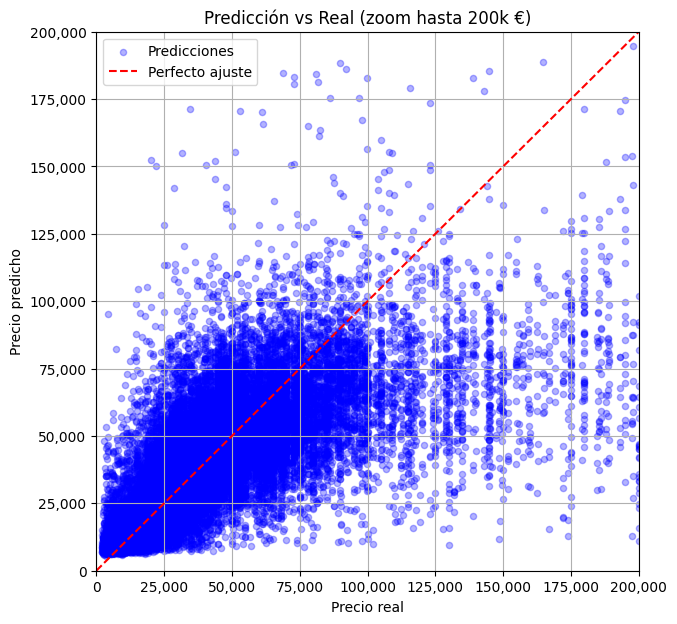

In [22]:
plt.figure(figsize=(7,7))
plt.scatter(y_test_real, np.expm1(gbr.predict(x_test)),
            alpha=0.3, s=20, color='blue', label='Predicciones')

plt.plot([0, 200_000], [0, 200_000], linestyle='--', color='red', label='Perfecto ajuste')

plt.xlim(0, 200_000)
plt.ylim(0, 200_000)

plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.title('Predicción vs Real (zoom hasta 200k €)')

plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.grid(True)
plt.legend()
plt.show()


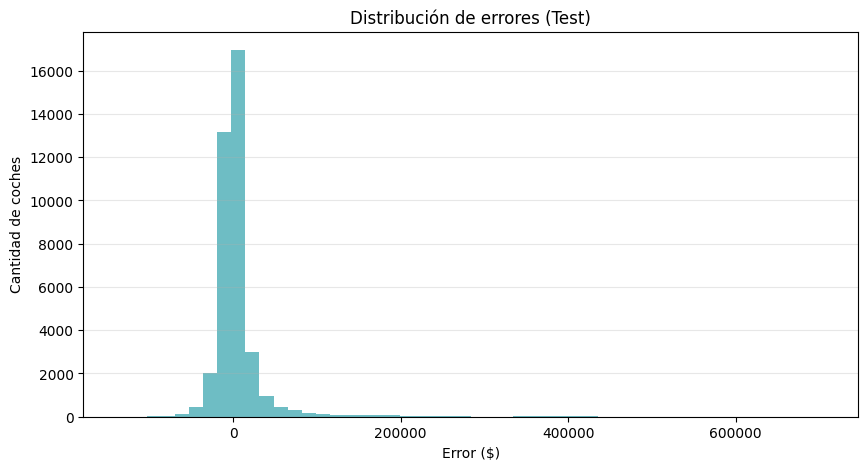

In [23]:
# Predicciones de test
y_pred_gbr_test = np.expm1(gbr.predict(x_test))

# Errores
errors = y_test_real - y_pred_gbr_test

# Histograma
plt.figure(figsize=(10,5))
plt.hist(errors, bins=50, color='#31A2AC', alpha=0.7)
plt.title('Distribución de errores (Test)')
plt.xlabel('Error ($)')
plt.ylabel('Cantidad de coches')
plt.grid(axis='y', alpha=0.3)
plt.show()


#### Comparar modelos

##### Comprobar overfiting de los modelos (%)

In [24]:
# Revertir y reales
y_train_real = np.expm1(y_train)
y_test_real  = np.expm1(y_test)

y_pred_gbr_train = np.expm1(gbr.predict(x_train))
y_pred_gbr_test  = np.expm1(gbr.predict(x_test))

y_pred_rf_train  = np.expm1(rf.predict(x_train))
y_pred_rf_test   = np.expm1(rf.predict(x_test))

y_pred_hgb_train = np.expm1(hgb.predict(x_train))
y_pred_hgb_test  = np.expm1(hgb.predict(x_test))

In [25]:
# MAE
mae_train_gbr = mean_absolute_error(y_train_real, y_pred_gbr_train)
mae_test_gbr  = mean_absolute_error(y_test_real, y_pred_gbr_test)

mae_train_rf = mean_absolute_error(y_train_real, y_pred_rf_train)
mae_test_rf  = mean_absolute_error(y_test_real, y_pred_rf_test)

mae_train_hgb = mean_absolute_error(y_train_real, y_pred_hgb_train)
mae_test_hgb  = mean_absolute_error(y_test_real, y_pred_hgb_test)

In [26]:
overfit_gbr = (mae_test_gbr - mae_train_gbr) / mae_train_gbr * 100
overfit_rf  = (mae_test_rf  - mae_train_rf)  / mae_train_rf  * 100
overfit_hgb = (mae_test_hgb - mae_train_hgb) / mae_train_hgb * 100

print("Overfitting (%) por modelo:")
print(f"GBR: {overfit_gbr:.2f}%")
print(f"RF:  {overfit_rf:.2f}%")
print(f"HGB: {overfit_hgb:.2f}%")

Overfitting (%) por modelo:
GBR: 1.87%
RF:  1.22%
HGB: 1.42%


##### Ver valores MAE, RMSE Y R2 de los modelos.

In [27]:
# --- Asegurarnos de tener y_train_real ---
y_train_real = np.expm1(y_train)

# --- Evaluar modelos en TRAIN ---
results_train = {
    'RF': evaluate_model(y_train_real, y_pred_rf_train),
    'GBR': evaluate_model(y_train_real, y_pred_gbr_train),
    'HGB': evaluate_model(y_train_real, y_pred_hgb_train),
}

# --- Convertir a DataFrame para ver resultados ---
pd.DataFrame(results_train).T

,MAE,RMSE,R2
RF,16027.161380,42103.907535,0.260452
GBR,15442.103717,40069.960124,0.330178
HGB,15532.380563,40404.012405,0.318963


#### Guardar modelos y predicciones

In [28]:
joblib.dump(hgb, "../models/csv1/hgb_model.pkl")
joblib.dump(y_test_real, "../models/csv1/y_test_real.pkl")
joblib.dump(y_pred_hgb_test, "../models/csv1/y_pred_hgb.pkl")

print("Modelo y predicciones guardadas ✅")

Modelo y predicciones guardadas ✅
